# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47
344,2016,12,28,Wed,42,47,45.3,48,58
345,2016,12,29,Thurs,47,48,45.3,48,65
346,2016,12,30,Fri,48,48,45.4,57,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [ ]:
df.info()       ##no hace falta pasar el dia de la semana a numerico porque no influye en la temperatura!

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


In [4]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


In [ ]:
df['week']      ##lo pasamos a numerico

0        Fri
1        Sat
2        Sun
3        Mon
4       Tues
       ...  
343     Tues
344      Wed
345    Thurs
346      Fri
347      Sat
Name: week, Length: 348, dtype: str

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['week_int'] = le.fit_transform(df['week'])
df

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int
0,2016,1,1,Fri,45,45,45.6,45,29,0
1,2016,1,2,Sat,44,45,45.7,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,56,3
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,5
...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47,5
344,2016,12,28,Wed,42,47,45.3,48,58,6
345,2016,12,29,Thurs,47,48,45.3,48,65,4
346,2016,12,30,Fri,48,48,45.4,57,42,0


In [ ]:
pd.get_dummies(df['week'])      ##crear una columna para cada dia de la semana y decir si True or False

,Fri,Mon,Sat,Sun,Thurs,Tues,Wed
0,True,False,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...
343,False,False,False,False,False,True,False
344,False,False,False,False,False,False,True
345,False,False,False,False,True,False,False
346,True,False,False,False,False,False,False


In [8]:
my_week = {
    "Mon":1,
    "Tues":2,
    "Wed":3,
    "Thurs":4,
    "Fri":5,
    "Sat":6,
    "Sun":7
}

df['week_int'] = df['week'].replace(my_week)
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int
0,2016,1,1,Fri,45,45,45.6,45,29,5
1,2016,1,2,Sat,44,45,45.7,44,61,6
2,2016,1,3,Sun,45,44,45.8,41,56,7
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,2


In [9]:
df['autumn'] = np.where(df['month'].isin([10,11,12]), 1, 0)
df['winter'] = np.where(df['month'].isin([1,2,3]), 1, 0)
df['spring'] = np.where(df['month'].isin([4,5,6]), 1, 0)
df['summer'] = np.where(df['month'].isin([7,8,9]), 1, 0)
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,autumn,winter,spring,summer
0,2016,1,1,Fri,45,45,45.6,45,29,5,0,1,0,0
1,2016,1,2,Sat,44,45,45.7,44,61,6,0,1,0,0
2,2016,1,3,Sun,45,44,45.8,41,56,7,0,1,0,0
3,2016,1,4,Mon,44,41,45.9,40,53,1,0,1,0,0
4,2016,1,5,Tues,41,40,46.0,44,41,2,0,1,0,0


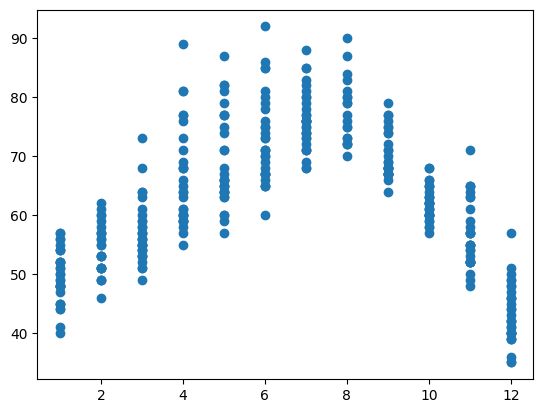

In [10]:
plt.scatter(df['month'], df['actual'])

In [11]:
df.corr(numeric_only=True)

,year,month,day,temp_2,temp_1,average,actual,friend,autumn,winter,spring,summer
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,1.000000,-0.000412,0.047651,0.032664,0.120806,0.004529,0.048145,0.772310,-0.745591,-0.251591,0.228408
day,NaN,-0.000412,1.000000,-0.046194,-0.000691,-0.021136,-0.021675,0.024592,0.011340,0.004328,0.010594,-0.027626
temp_2,NaN,0.047651,-0.046194,1.000000,0.857800,0.821560,0.805835,0.583758,-0.382375,-0.458992,0.331928,0.531575
temp_1,NaN,0.032664,-0.000691,0.857800,1.000000,0.819328,0.877880,0.541282,-0.391054,-0.447745,0.333996,0.526819
average,NaN,0.120806,-0.021136,0.821560,0.819328,1.000000,0.848365,0.689278,-0.434943,-0.523831,0.260625,0.729693
actual,NaN,0.004529,-0.021675,0.805835,0.877880,0.848365,1.000000,0.569145,-0.436088,-0.437172,0.351225,0.545100
friend,NaN,0.048145,0.024592,0.583758,0.541282,0.689278,0.569145,1.000000,-0.350818,-0.340658,0.214924,0.498278
autumn,NaN,0.772310,0.011340,-0.382375,-0.391054,-0.434943,-0.436088,-0.350818,1.000000,-0.346185,-0.354086,-0.319830
winter,NaN,-0.745591,0.004328,-0.458992,-0.447745,-0.523831,-0.437172,-0.340658,-0.346185,1.000000,-0.346185,-0.312694


In [12]:
my_month = {
    10:1,
    11:2,
    12:3,
    1:4,
    2:5,
    3:6,
    4:7,
    5:8,
    6:9,
    7:10,
    8:11,
    9:12    
}
df['self_month'] = df['month'].replace(my_month)
df

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,autumn,winter,spring,summer,self_month
0,2016,1,1,Fri,45,45,45.6,45,29,5,0,1,0,0,4
1,2016,1,2,Sat,44,45,45.7,44,61,6,0,1,0,0,4
2,2016,1,3,Sun,45,44,45.8,41,56,7,0,1,0,0,4
3,2016,1,4,Mon,44,41,45.9,40,53,1,0,1,0,0,4
4,2016,1,5,Tues,41,40,46.0,44,41,2,0,1,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47,2,1,0,0,0,3
344,2016,12,28,Wed,42,47,45.3,48,58,3,1,0,0,0,3
345,2016,12,29,Thurs,47,48,45.3,48,65,4,1,0,0,0,3
346,2016,12,30,Fri,48,48,45.4,57,42,5,1,0,0,0,3


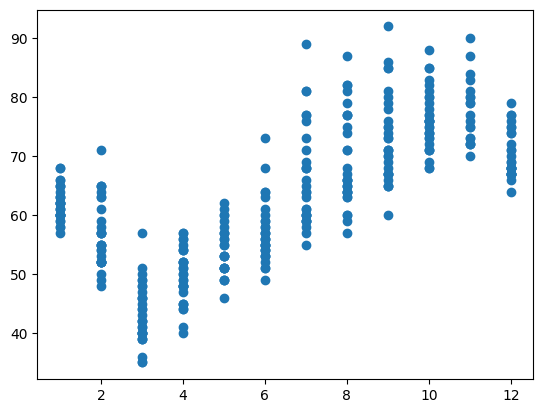

In [13]:
plt.scatter(df['self_month'], df['actual'])

##Parece que a meses más altos sube la temperatura. Con la excepción de Enero, Febrero, Noviembre y Diciembre. Parece que tenemos una codificación Ordinal.

In [14]:
df.corr(numeric_only=True)

,year,month,day,temp_2,temp_1,average,actual,friend,autumn,winter,spring,summer,self_month
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,1.000000,-0.000412,0.047651,0.032664,0.120806,0.004529,0.048145,0.772310,-0.745591,-0.251591,0.228408,-0.170411
day,NaN,-0.000412,1.000000,-0.046194,-0.000691,-0.021136,-0.021675,0.024592,0.011340,0.004328,0.010594,-0.027626,-0.018014
temp_2,NaN,0.047651,-0.046194,1.000000,0.857800,0.821560,0.805835,0.583758,-0.382375,-0.458992,0.331928,0.531575,0.642092
temp_1,NaN,0.032664,-0.000691,0.857800,1.000000,0.819328,0.877880,0.541282,-0.391054,-0.447745,0.333996,0.526819,0.640155
average,NaN,0.120806,-0.021136,0.821560,0.819328,1.000000,0.848365,0.689278,-0.434943,-0.523831,0.260625,0.729693,0.798806
actual,NaN,0.004529,-0.021675,0.805835,0.877880,0.848365,1.000000,0.569145,-0.436088,-0.437172,0.351225,0.545100,0.681100
friend,NaN,0.048145,0.024592,0.583758,0.541282,0.689278,0.569145,1.000000,-0.350818,-0.340658,0.214924,0.498278,0.593650
autumn,NaN,0.772310,0.011340,-0.382375,-0.391054,-0.434943,-0.436088,-0.350818,1.000000,-0.346185,-0.354086,-0.319830,-0.757565
winter,NaN,-0.745591,0.004328,-0.458992,-0.447745,-0.523831,-0.437172,-0.340658,-0.346185,1.000000,-0.346185,-0.312694,-0.229156


In [15]:
df.groupby('month')['actual'].mean()

month
1     49.741935
2     54.346154
3     57.096774
4     66.266667
5     69.193548
6     73.033333
7     76.225806
8     77.789474
9     70.321429
10    62.000000
11    56.733333
12    43.354839
Name: actual, dtype: float64

In [16]:
df["avg_temp_month_2"]=df.groupby('month')['actual'].transform("mean")
df.describe()
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,autumn,winter,spring,summer,self_month,avg_temp_month_2
0,2016,1,1,Fri,45,45,45.6,45,29,5,0,1,0,0,4,49.741935
1,2016,1,2,Sat,44,45,45.7,44,61,6,0,1,0,0,4,49.741935
2,2016,1,3,Sun,45,44,45.8,41,56,7,0,1,0,0,4,49.741935
3,2016,1,4,Mon,44,41,45.9,40,53,1,0,1,0,0,4,49.741935
4,2016,1,5,Tues,41,40,46.0,44,41,2,0,1,0,0,4,49.741935


<Axes: xlabel='avg_temp_month_2', ylabel='actual'>

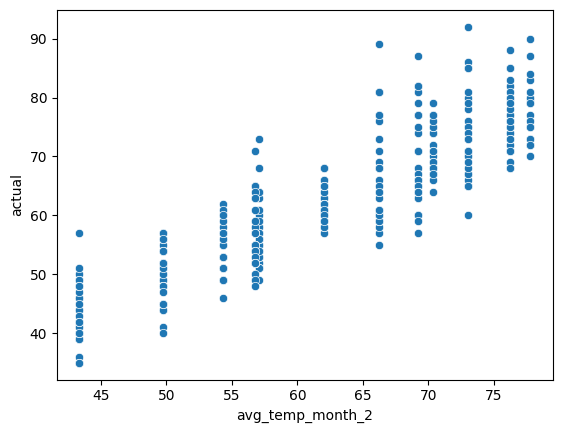

In [17]:
sns.scatterplot(df,x="avg_temp_month_2",y="actual")

In [18]:
df

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,autumn,winter,spring,summer,self_month,avg_temp_month_2
0,2016,1,1,Fri,45,45,45.6,45,29,5,0,1,0,0,4,49.741935
1,2016,1,2,Sat,44,45,45.7,44,61,6,0,1,0,0,4,49.741935
2,2016,1,3,Sun,45,44,45.8,41,56,7,0,1,0,0,4,49.741935
3,2016,1,4,Mon,44,41,45.9,40,53,1,0,1,0,0,4,49.741935
4,2016,1,5,Tues,41,40,46.0,44,41,2,0,1,0,0,4,49.741935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47,2,1,0,0,0,3,43.354839
344,2016,12,28,Wed,42,47,45.3,48,58,3,1,0,0,0,3,43.354839
345,2016,12,29,Thurs,47,48,45.3,48,65,4,1,0,0,0,3,43.354839
346,2016,12,30,Fri,48,48,45.4,57,42,5,1,0,0,0,3,43.354839


<Axes: >

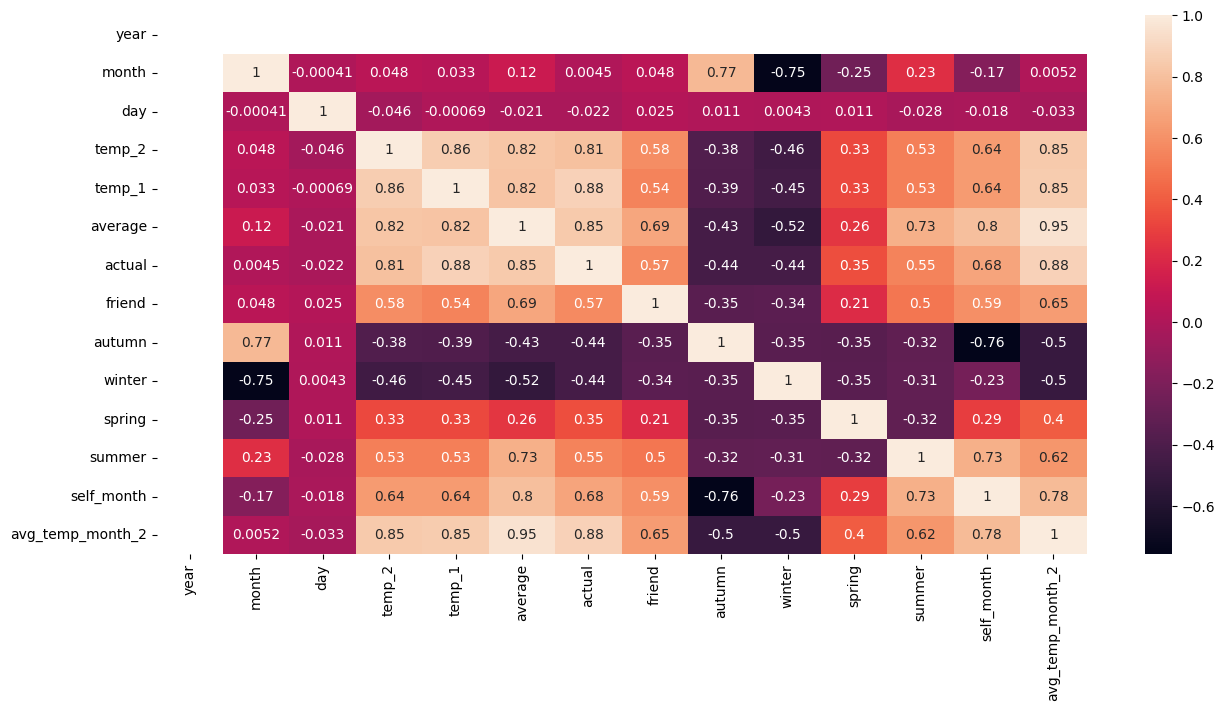

In [19]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
## pairplot hacer !!

### 3. Selecciona variables y divide en train y test

In [ ]:
X = df[["temp_2", "temp_1", "self_month", "avg_temp_month_2", 'average']]       ##son las variables que mas correlacionan segun el heatmap
y = df['actual']

##No cogemos las de las estaciones porque ya tenemos avg_temp_month y tienen un correlación alta con esa, que es más precisa.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 5)
(70, 5)
(278,)
(70,)


### 4. Entrena el modelo


In [22]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [23]:
dtr.score(X_train, y_train)

1.0

1.0, resultado malo

In [24]:
dtr.score(X_test, y_test)

0.6951297829361419

##0.69 es Overfitting en R2

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

y_pred = dtr.predict(X_test)

print("MAE", mean_absolute_error(y_test, y_pred))           ## 5, ok
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))   ##error porcentual
print("MSE", mean_squared_error(y_test, y_pred))            ##esta en las unidades del target y al cuadrado
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))      ##overfit se deduce comparando metricas de test y de train. Combiene sacar datos de train
dtr.score(X_test,y_test)

MAE 5.114285714285714
MAPE 0.08189919004757695
MSE 42.628571428571426
RMSE 6.529055937007389


0.6951297829361419

### 6. Representa el árbol de decisión

In [26]:
from sklearn.tree import plot_tree

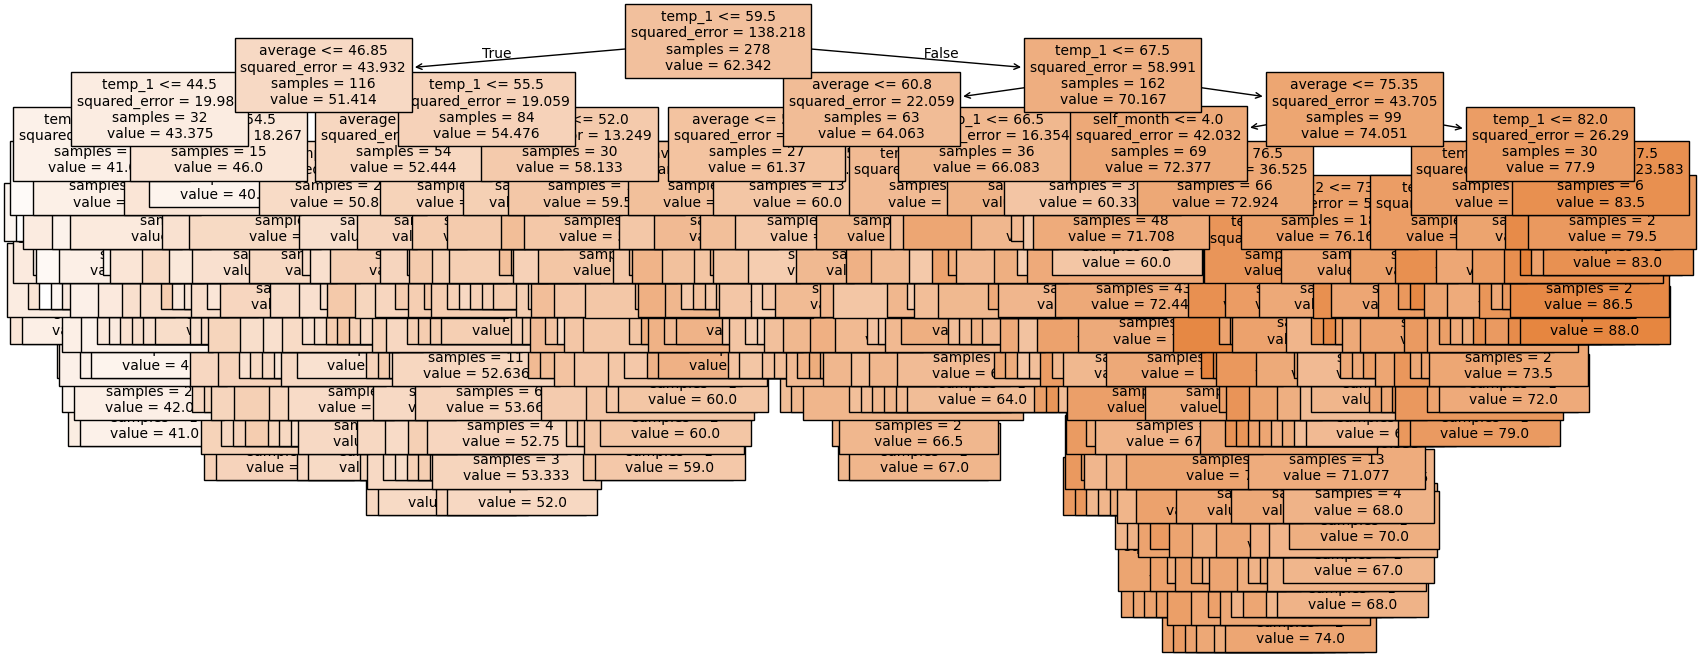

In [27]:
plt.figure(figsize=(20,8))
plot_tree(dtr, fontsize=10, feature_names=X_train.columns, filled=True);

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [ ]:
dtr = DecisionTreeRegressor(max_depth=3)        ##queremos regresion, no clasificacion
dtr.fit(X_train, y_train)

print("R2 train", dtr.score(X_train, y_train))
print("R2 test", dtr.score(X_test, y_test))

R2 train 0.8397458755018086
R2 test 0.7786776796296856


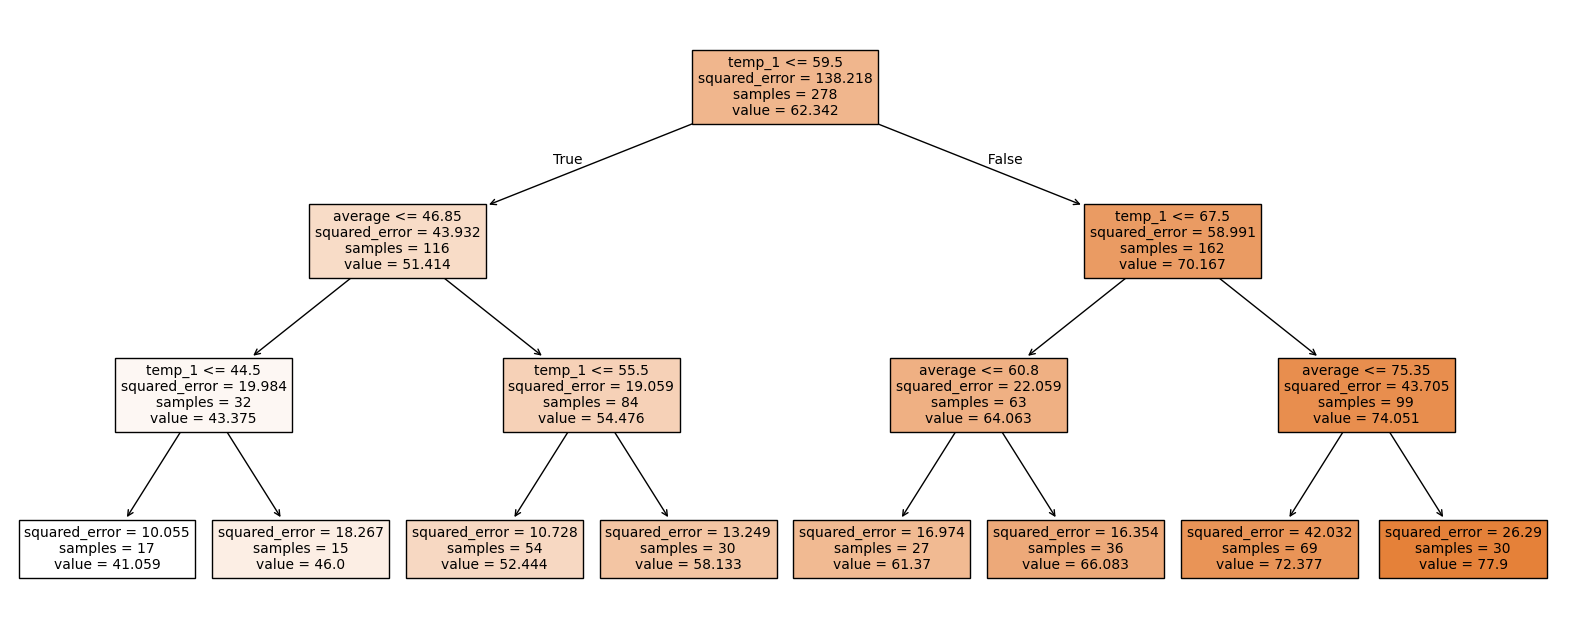

In [29]:
plt.figure(figsize=(20,8))
plot_tree(dtr, fontsize=10, feature_names=X_train.columns, filled=True);

### 8. Vuelve a evaluar tu modelo

In [30]:
y_pred = dtr.predict(X_test)

print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE 4.267242249556827
MAPE 0.0674392768128964
MSE 30.946461197509944
RMSE 5.5629543587476915


### 9. Vuelve a representar su árbol

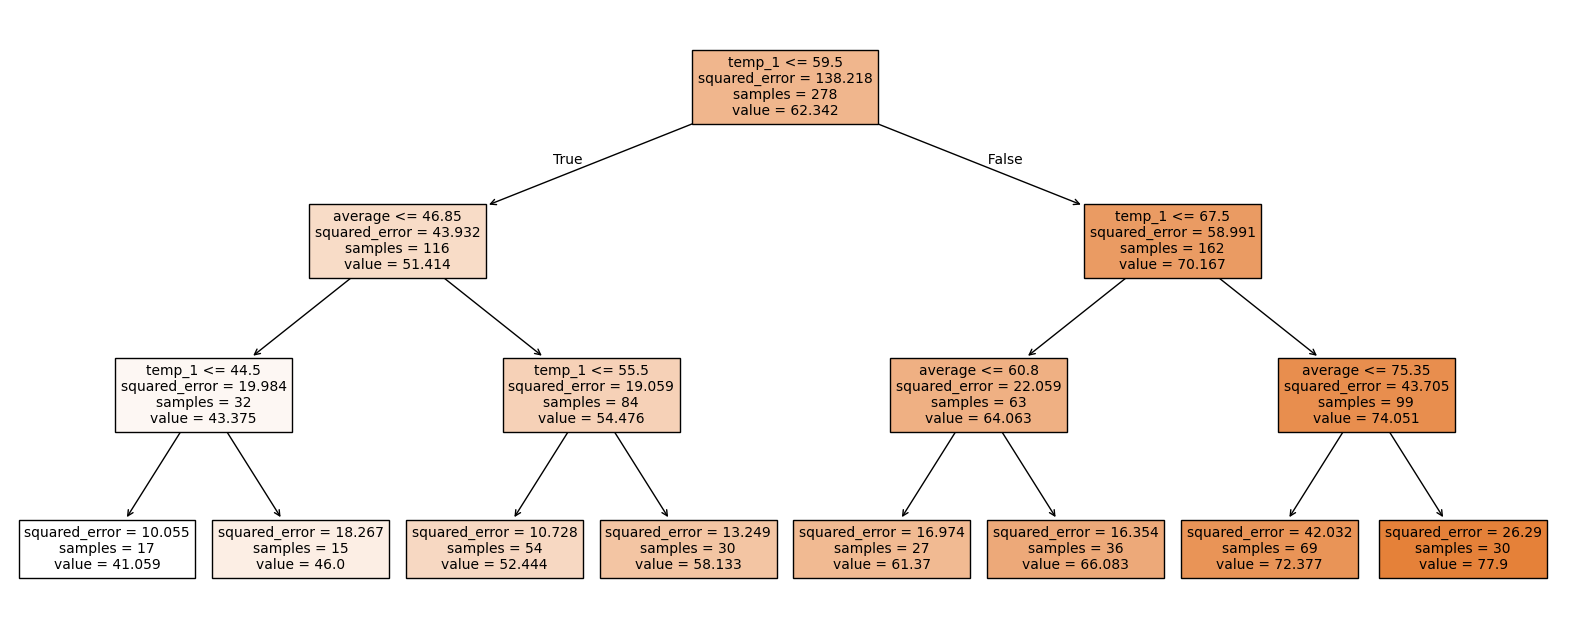

In [31]:
plt.figure(figsize=(20,8))
plot_tree(dtr, fontsize=10, feature_names=X_train.columns, filled=True);

In [32]:
dtr.feature_importances_

array([0.        , 0.88110924, 0.        , 0.        , 0.11889076])

In [33]:
X.columns

Index(['temp_2', 'temp_1', 'self_month', 'avg_temp_month_2', 'average'], dtype='str')

In [ ]:
feat = pd.Series(dtr.feature_importances_,index=X.columns)
feat.sort_values(ascending=False)           ## sale que el mejor predictor es la temperatura del dia anterior
feat

temp_2              0.000000
temp_1              0.881109
self_month          0.000000
avg_temp_month_2    0.000000
average             0.118891
dtype: float64

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [ ]:
from sklearn.model_selection import GridSearchCV        ## para probar diferentes combinaciones

In [ ]:
model = DecisionTreeRegressor()

parameters = {
    "max_depth" : [2,3,4,5],            ## prueba diferentes depths y se queda con la mejor: 4x3x2=24 combinaciones. Cross validation de 5, 120
    "min_samples_leaf": [10,20,30],
}

dtr_gs = GridSearchCV(model, parameters, cv=5, scoring="neg_mean_absolute_error")

In [39]:
X_train.shape

(278, 5)

In [40]:
dtr_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [41]:
dtr_gs.best_params_

{'max_depth': 4, 'min_samples_leaf': 10}

In [42]:
dtr_gs.best_score_

np.float64(-4.109792852635946)

In [43]:
dtr_gs.best_estimator_

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [44]:
best_dtr = dtr_gs.best_estimator_

In [45]:
y_pred = best_dtr.predict(X_test)

print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE 3.752619628712729
MAPE 0.05993153951020385
MSE 23.528933039948996
RMSE 4.850663154657206


In [46]:
model = DecisionTreeRegressor(max_depth= 5, min_samples_leaf= 10)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [47]:
y_pred = model.predict(X_test)

print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE 3.8221960698154867
MAPE 0.06057817440018146
MSE 24.588923167229407
RMSE 4.958721928806797


In [48]:
from sklearn.model_selection import cross_val_score

results_cv = cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
print(results_cv)
print(results_cv.mean())
print(results_cv.std())

[-3.57566416 -7.10098568 -4.42700153 -3.57225319 -4.30606534]
-4.596393980233932
1.3020535958603199


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [49]:
X.columns

Index(['temp_2', 'temp_1', 'self_month', 'avg_temp_month_2', 'average'], dtype='str')

In [ ]:
model.feature_importances_          ## temp_1 es la más importante

array([0.        , 0.86817269, 0.        , 0.        , 0.13182731])

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df['target_c'] = np.where(df['actual']>59, 1, 0)        ##columna target nueva, donde 0 de >59
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,autumn,winter,spring,summer,self_month,avg_temp_month_2,target_c
0,2016,1,1,Fri,45,45,45.6,45,29,5,0,1,0,0,4,49.741935,0
1,2016,1,2,Sat,44,45,45.7,44,61,6,0,1,0,0,4,49.741935,0
2,2016,1,3,Sun,45,44,45.8,41,56,7,0,1,0,0,4,49.741935,0
3,2016,1,4,Mon,44,41,45.9,40,53,1,0,1,0,0,4,49.741935,0
4,2016,1,5,Tues,41,40,46.0,44,41,2,0,1,0,0,4,49.741935,0


In [53]:
df['target_c'].value_counts(normalize=True)

target_c
1    0.586207
0    0.413793
Name: proportion, dtype: float64

In [54]:
X = df[['temp_1', "average"]]
y = df['target_c']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(278, 2)
(70, 2)
(278,)
(70,)


In [55]:
model = DecisionTreeClassifier()

parameters = {
    "max_depth" : [2,3,4,5],
    "min_samples_leaf": [10,20,30],
}

dtc_gs = GridSearchCV(model, parameters, cv=5, scoring="precision")

In [56]:
dtc_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [57]:
dtc_gs.best_params_

{'max_depth': 3, 'min_samples_leaf': 10}

In [58]:
dtc_gs.best_score_

np.float64(0.8893271261692315)

In [59]:
dtc_gs.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [60]:
model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10)
# model = dtc_gs.best_estimator_
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [61]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix

In [62]:
y_pred = model.predict(X_test)

print("Accuracy", model.score(X_test, y_test))
print("AUC", roc_auc_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("Confusion matrix \n", confusion_matrix(y_test, y_pred))

Accuracy 0.9142857142857143
AUC 0.8988095238095237
Recall 0.9761904761904762
Precision 0.8913043478260869
F1 Score 0.9318181818181818
Confusion matrix 
 [[23  5]
 [ 1 41]]


In [63]:
model.feature_importances_

array([0.09308687, 0.90691313])

<BarContainer object of 2 artists>

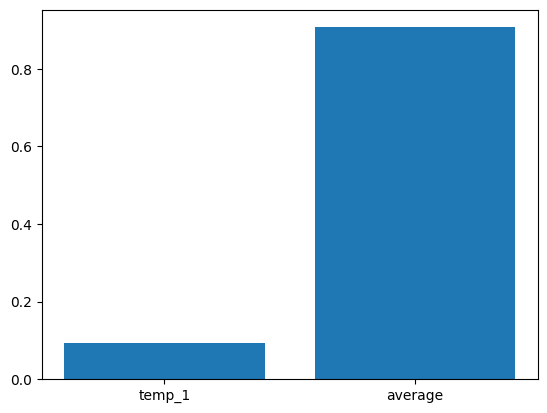

In [64]:
plt.bar(x=X.columns, height = model.feature_importances_)